# Customer Churn Prediction — Cleaned Pipeline

Fixes applied vs. the original notebook export:

1. Removed undefined variables (`total_charges_col`, `other_numeric`, `y_train_num`/`y_test_num`) by defining them explicitly and using **one consistent target encoding** (0/1 via `LabelEncoder`) throughout.
2. Removed the duplicate/contradictory balancing strategy. Only `class_weight='balanced'` is used by default (set `USE_ADASYN = True` below to try oversampling instead — don't use both at once).
3. Fixed execution order: preprocessor and feature lists are defined before anything that references them.
4. Added missing imports (`ImbPipeline`, `HalvingGridSearchCV` + its experimental enable flag).
5. Fixed the SHAP feature-name list to match the actual transformed column order.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, TargetEncoder, PowerTransformer, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.experimental import enable_halving_search_cv  # noqa: F401 (required to unlock HalvingGridSearchCV)
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    classification_report, precision_recall_fscore_support, ConfusionMatrixDisplay
)
from sklearn.impute import SimpleImputer

# Set USE_ADASYN=True to oversample the minority class instead of using
# class_weight='balanced'. Don't combine both — stacking oversampling on
# top of class weighting over-corrects and usually hurts precision.
USE_ADASYN = False

## 1. Load data

In [2]:
df = pd.read_csv("../data/processed_data/processed_customer_churn.csv ")
data = df.drop('customerID', axis=1).copy()


y_raw = data['Churn']
X = data.drop('Churn', axis=1)

# Single, consistent 0/1 target encoding used everywhere downstream.
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)  # 'No' -> 0, 'Yes' -> 1
print("Target classes:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

Target classes: {'No': np.int64(0), 'Yes': np.int64(1)}


In [3]:
# ==========================================================
# Feature Engineering
# Create new features from existing customer information
# ==========================================================

# Make a copy to avoid modifying the original dataframe
X = X.copy()

# ----------------------------------------------------------
# 1. Average Monthly Spending
# Estimate the customer's average monthly payment.
# Add 1 to tenure to avoid division by zero.
# ----------------------------------------------------------
X["AvgMonthlyCharge"] = X["TotalCharges"] / (X["tenure"] + 1)


# ----------------------------------------------------------
# 2. New Customer
# Customers with tenure <= 12 months are considered new.
# ----------------------------------------------------------
X["NewCustomer"] = (X["tenure"] <= 12).astype(int)


# ----------------------------------------------------------
# 3. Long-Term Contract
# Month-to-month = 0
# One year / Two year = 1
# ----------------------------------------------------------
X["LongContract"] = (
    X["Contract"] != "Month-to-month"
).astype(int)


# ----------------------------------------------------------
# 4. Number of Services
# Count how many services each customer is subscribed to.
# ----------------------------------------------------------
service_columns = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

X["NumServices"] = (
    X[service_columns]
    .eq("Yes")
    .sum(axis=1)
)

print("New shape:", X.shape)

New shape: (7043, 23)


In [4]:
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Data loaded. Train/test shapes:", x_train.shape, x_test.shape)
print("Train class balance:")
print(pd.Series(y_train).value_counts(normalize=True))

Data loaded. Train/test shapes: (5634, 23) (1409, 23)
Train class balance:
0    0.734647
1    0.265353
Name: proportion, dtype: float64


## 2. Feature groups

Defined explicitly, *before* the preprocessor that uses them.

In [5]:
total_charges_col = ['TotalCharges']
numerical_features = list(x_train.select_dtypes(include='number').columns)
other_numeric = [c for c in numerical_features if c not in total_charges_col]
categorical_features = list(x_train.select_dtypes(exclude='number').columns)

print("Total charges col:", total_charges_col)
print("Other numeric:", other_numeric)
print("Categorical:", categorical_features)

Total charges col: ['TotalCharges']
Other numeric: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'AvgMonthlyCharge', 'NewCustomer', 'LongContract', 'NumServices']
Categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 3. Exploratory: `TotalCharges` skew before/after transforms

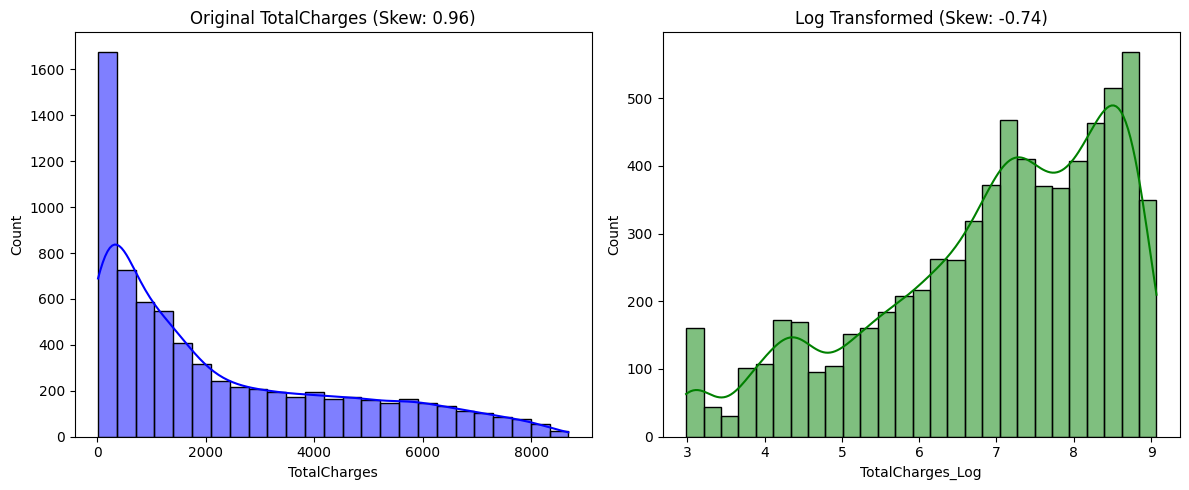

In [6]:
df_plot = data.copy()
df_plot['TotalCharges'] = df_plot["TotalCharges"].fillna(df_plot["TotalCharges"].median())
df_plot['TotalCharges_Log'] = np.log1p(df_plot['TotalCharges'])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df_plot['TotalCharges'], kde=True, ax=axes[0], color='blue')
axes[0].set_title(f"Original TotalCharges (Skew: {df_plot['TotalCharges'].skew():.2f})")
sns.histplot(df_plot['TotalCharges_Log'], kde=True, ax=axes[1], color='green')
axes[1].set_title(f"Log Transformed (Skew: {df_plot['TotalCharges_Log'].skew():.2f})")
plt.tight_layout()
plt.show()

In [7]:
pt = PowerTransformer(method='yeo-johnson')
total_charges_yj = pt.fit_transform(df_plot[['TotalCharges']])
print(f"Yeo-Johnson skew: {pd.Series(total_charges_yj.flatten()).skew():.2f}")

Yeo-Johnson skew: -0.14


## 4. Preprocessing pipeline

In [8]:
charges_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('yeo-johnson', PowerTransformer(method='yeo-johnson')),
    ('scaler', StandardScaler())
])

other_num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('charges', charges_transformer, total_charges_col),
    ('num', other_num_transformer, other_numeric),
    ('cat', categorical_transformer, categorical_features),
])

## 5. Model pipelines

Toggle `USE_ADASYN` above to switch strategies. By default we use `class_weight='balanced'` only.

In [9]:
if USE_ADASYN:
    from imblearn.pipeline import Pipeline as ImbPipeline
    from imblearn.over_sampling import ADASYN

    pipe_lr = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('sampling', ADASYN(random_state=42)),
        ('classifier', LogisticRegression(random_state=42, max_iter=1000)),
    ])
    pipe_rf = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('sampling', ADASYN(random_state=42)),
        ('classifier', RandomForestClassifier(random_state=42)),
    ])
else:
    pipe_lr = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')),
    ])
    pipe_rf = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced')),
    ])

In [10]:
param_grid_lr = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__solver': ['liblinear', 'lbfgs']
}
param_grid_rf = {
    'classifier__n_estimators': [200, 400],
    'classifier__max_depth': [10, 20, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__max_features': ['sqrt', 'log2']
}
grid_lr = HalvingGridSearchCV(pipe_lr, param_grid_lr, cv=5, factor=2, scoring='f1', n_jobs=-1, random_state=42)
grid_lr.fit(x_train, y_train)

grid_rf = HalvingGridSearchCV(pipe_rf, param_grid_rf, cv=5, factor=2, scoring='f1', n_jobs=-1, random_state=42)
grid_rf.fit(x_train, y_train)

print(f"Best LR Params: {grid_lr.best_params_}")
print(f"Best RF Params: {grid_rf.best_params_}")

Best LR Params: {'classifier__C': 10, 'classifier__solver': 'liblinear'}
Best RF Params: {'classifier__max_depth': 20, 'classifier__max_features': 'log2', 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 400}


## 5b. XGBoost model

Same `preprocessor`, same `HalvingGridSearchCV` pattern as the LR/RF models above, so it's a direct apples-to-apples comparison. Class imbalance is handled via `scale_pos_weight` (XGBoost's equivalent of `class_weight='balanced'`) rather than oversampling — consistent with the `USE_ADASYN=False` choice made earlier.

In [11]:
from xgboost import XGBClassifier

# scale_pos_weight ~= (# negative) / (# positive) in the training set,
# mirroring what class_weight='balanced' does for LR/RF.
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.3f}")

pipe_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        random_state=42,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        n_jobs=-1,
    )),
])

param_grid_xgb = {
    'classifier__n_estimators': [200, 400],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__subsample': [0.8, 1.0],
    'classifier__colsample_bytree': [0.8, 1.0],
    'classifier__gamma': [0, 1],
    'classifier__min_child_weight': [1, 3]
}

grid_xgb = HalvingGridSearchCV(
    pipe_xgb, param_grid_xgb, cv=5, factor=2, scoring='f1', n_jobs=-1, random_state=42
)
grid_xgb.fit(x_train, y_train)

print(f"Best XGBoost Params: {grid_xgb.best_params_}")

scale_pos_weight: 2.769
Best XGBoost Params: {'classifier__colsample_bytree': 1.0, 'classifier__gamma': 1, 'classifier__learning_rate': 0.01, 'classifier__max_depth': 5, 'classifier__min_child_weight': 1, 'classifier__n_estimators': 200, 'classifier__subsample': 0.8}


## 6. Performance comparison

In [12]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def get_metrics(model, x, y_true, pos_label=1):
    y_pred = model.predict(x)

    accuracy = accuracy_score(y_true, y_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average='binary',
        pos_label=pos_label
    )

    return {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }
def get_metrics(model, x, y_true, pos_label=1):
    y_pred = model.predict(x)

    accuracy = accuracy_score(y_true, y_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average='binary',
        pos_label=pos_label
    )

    return {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }

results = {
    'Logistic Regression': get_metrics(grid_lr, x_test, y_test),
    'Random Forest': get_metrics(grid_rf, x_test, y_test),
    'XGBoost': get_metrics(grid_xgb, x_test, y_test),
}
results_df = pd.DataFrame(results).T
results_df.style.highlight_max(axis=0, color='lightgreen')

,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.743790,0.511265,0.788770,0.620400
Random Forest,0.761533,0.535581,0.764706,0.629956
XGBoost,0.758694,0.530466,0.791444,0.635193


## 7. Random Forest feature importance

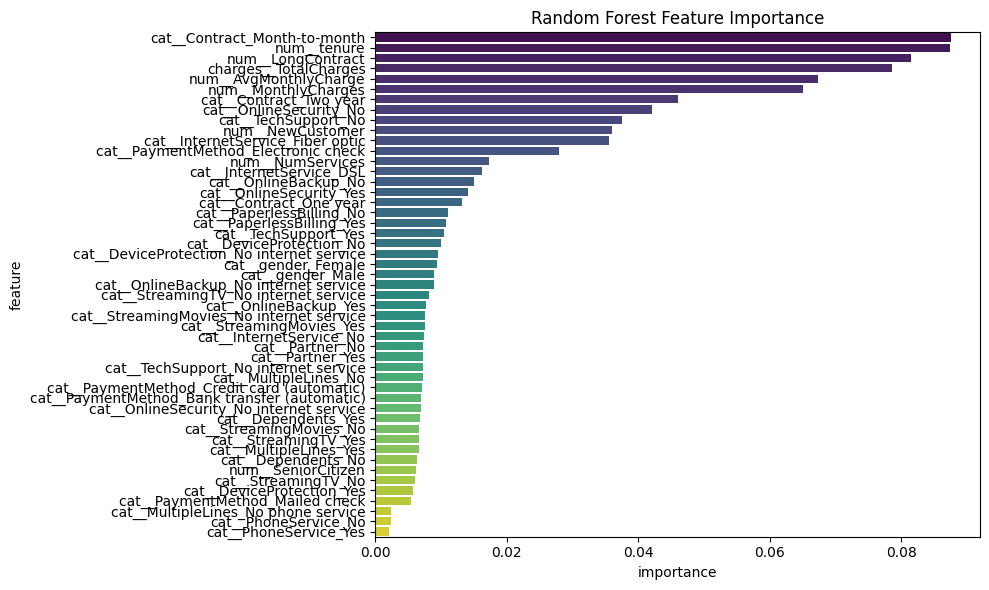

,feature,importance
40,cat__Contract_Month-to-month,0.087637
2,num__tenure,0.087443
6,num__LongContract,0.081479
0,charges__TotalCharges,0.078634
4,num__AvgMonthlyCharge,0.067389
3,num__MonthlyCharges,0.065094
42,cat__Contract_Two year,0.046088
22,cat__OnlineSecurity_No,0.042090
31,cat__TechSupport_No,0.037485
5,num__NewCustomer,0.035984


In [13]:
best_pipeline = grid_rf.best_estimator_

feature_names = best_pipeline.named_steps[
    'preprocessor'
].get_feature_names_out()

best_rf_model = best_pipeline.named_steps['classifier']

importances = pd.DataFrame({
    'feature': feature_names,
    'importance': best_rf_model.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=importances, hue='feature', palette='viridis', legend=False)
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

importances.head(20)

## 7b. XGBoost feature importance

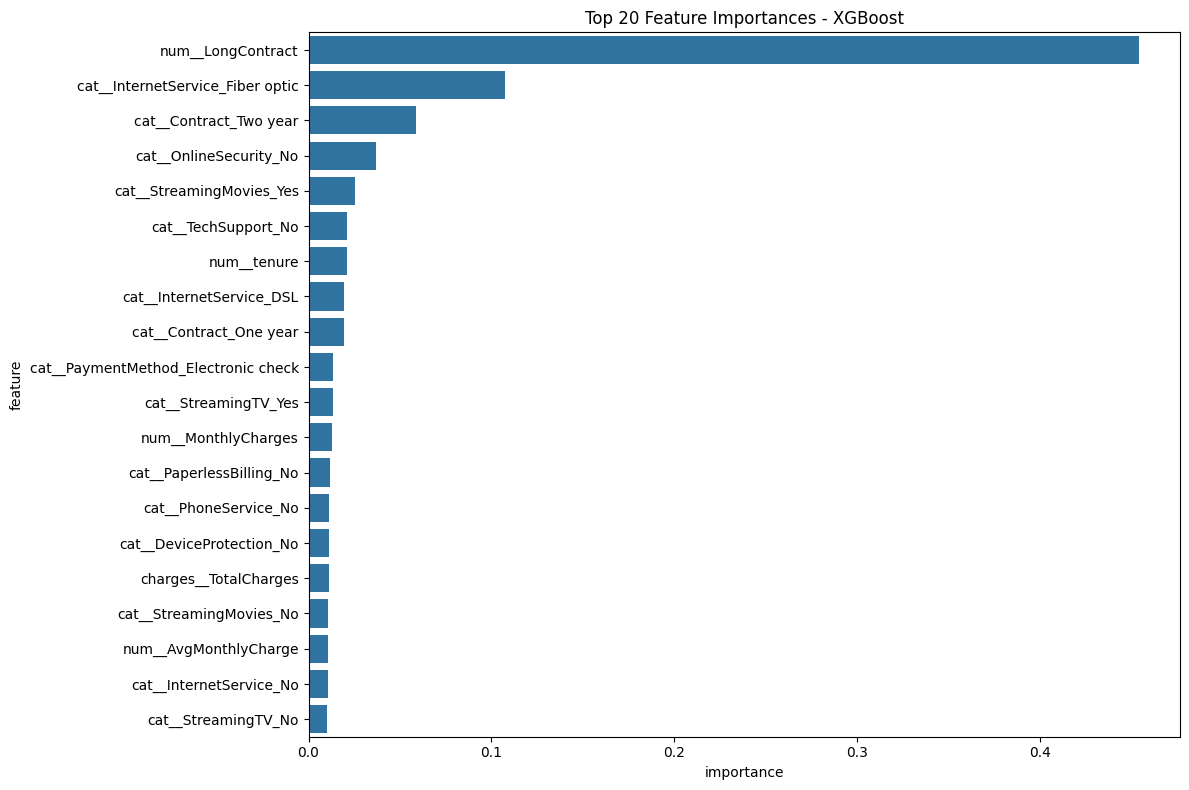

,feature,importance
6,num__LongContract,0.453610
20,cat__InternetService_Fiber optic,0.107575
42,cat__Contract_Two year,0.058773
22,cat__OnlineSecurity_No,0.036753
39,cat__StreamingMovies_Yes,0.025672
31,cat__TechSupport_No,0.021193
2,num__tenure,0.020776
19,cat__InternetService_DSL,0.019568
41,cat__Contract_One year,0.019293
47,cat__PaymentMethod_Electronic check,0.013578


In [14]:
best_pipeline_xgb = grid_xgb.best_estimator_

preprocessor = best_pipeline_xgb.named_steps['preprocessor']
best_xgb_model = best_pipeline_xgb.named_steps['classifier']

feature_names = preprocessor.get_feature_names_out()

importances_xgb = pd.DataFrame({
    'feature': feature_names,
    'importance': best_xgb_model.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(
    data=importances_xgb.head(20),
    x='importance',
    y='feature'
)

plt.title("Top 20 Feature Importances - XGBoost")
plt.tight_layout()
plt.show()

importances_xgb.head(20)

## 8. SHAP explanations

Requires `pip install shap`. Skips gracefully if not installed.

In [15]:
best_pipeline = grid_rf.best_estimator_

preprocessor = best_pipeline.named_steps['preprocessor']
best_rf_model = best_pipeline.named_steps['classifier']

Calculating SHAP values for Random Forest...


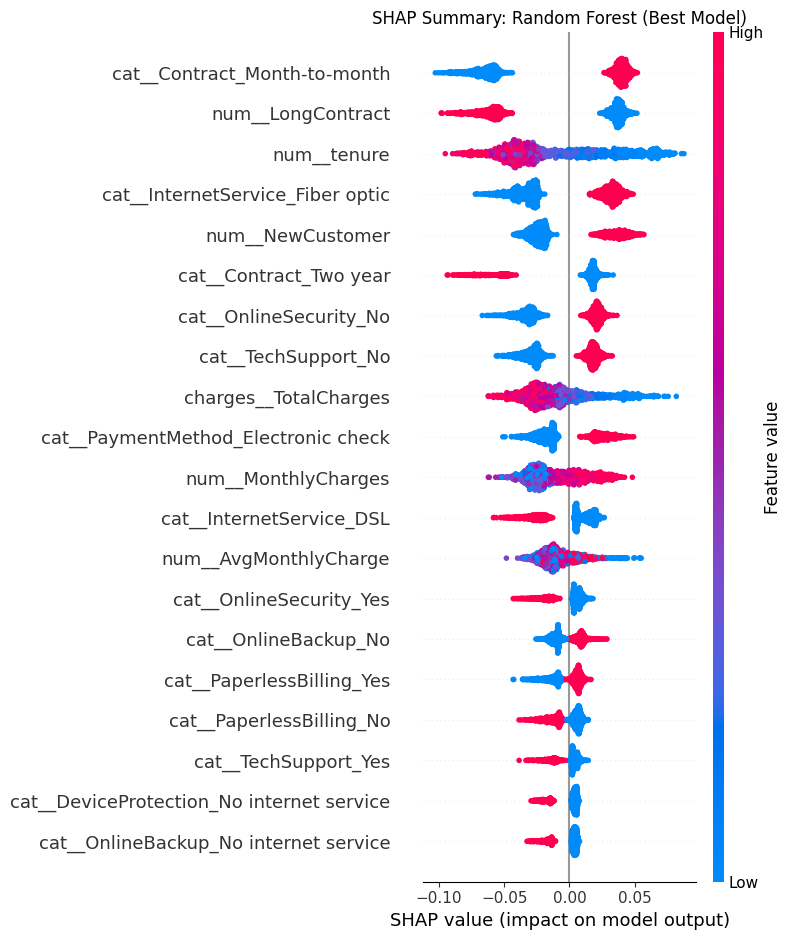

Background dataset has 1409 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1409 when initializing the masker.


Calculating SHAP values for Logistic Regression...


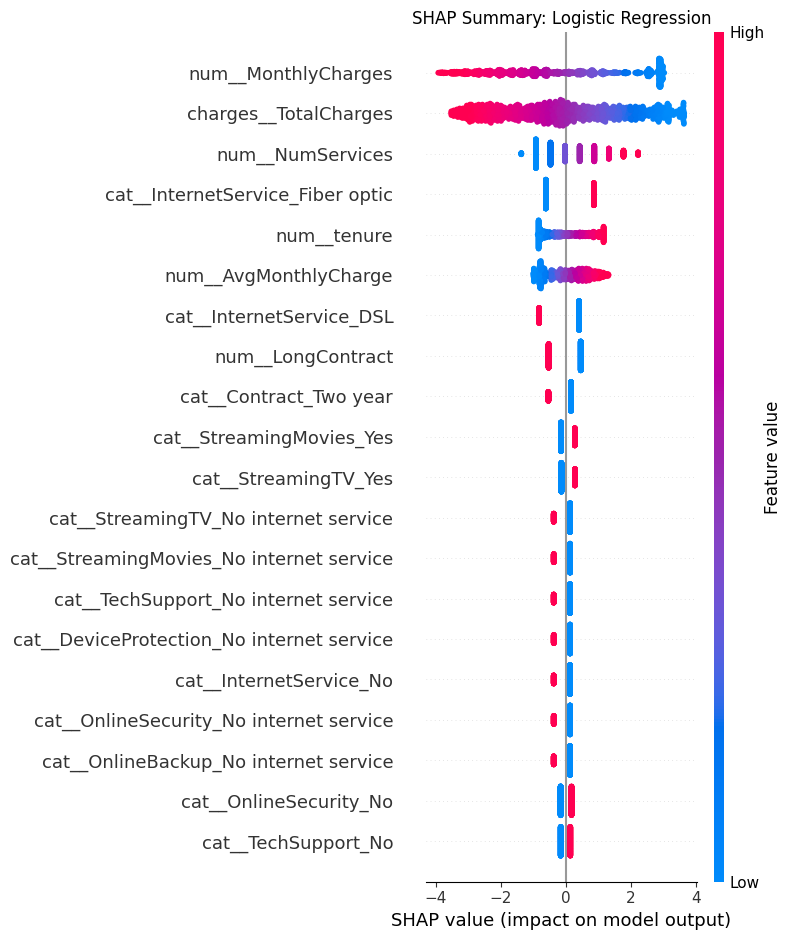

Calculating SHAP values for XGBoost...


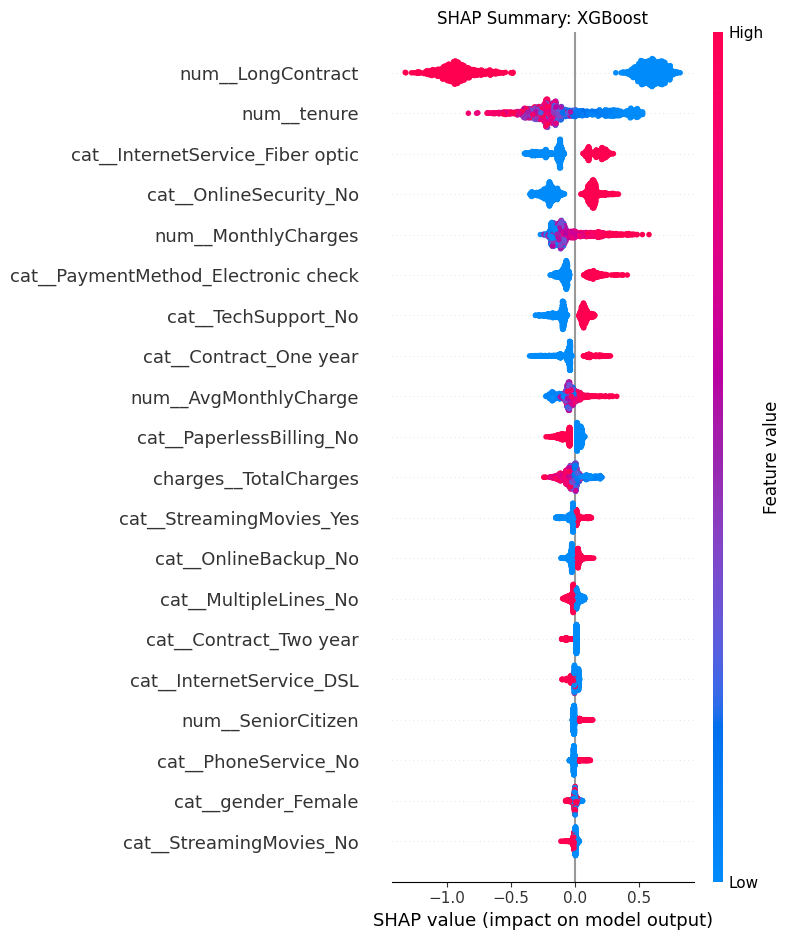

In [16]:
try:
    import shap

    X_test_proc = preprocessor.transform(x_test)
    feature_names_proc = preprocessor.get_feature_names_out()
    print("Calculating SHAP values for Random Forest...")
    explainer_rf = shap.TreeExplainer(best_rf_model)
    shap_values_rf = explainer_rf.shap_values(X_test_proc)
    vals = shap_values_rf[..., 1] if np.ndim(shap_values_rf) == 3 else shap_values_rf

    shap.summary_plot(vals, X_test_proc, feature_names=feature_names_proc, show=False)
    plt.title("SHAP Summary: Random Forest (Best Model)")
    plt.tight_layout()
    plt.show()

    print("Calculating SHAP values for Logistic Regression...")
    explainer_lr = shap.LinearExplainer(grid_lr.best_estimator_.named_steps['classifier'], X_test_proc)
    shap_values_lr = explainer_lr.shap_values(X_test_proc)

    shap.summary_plot(shap_values_lr, X_test_proc, feature_names=feature_names_proc, show=False)
    plt.title("SHAP Summary: Logistic Regression")
    plt.tight_layout()
    plt.show()

    print("Calculating SHAP values for XGBoost...")
    explainer_xgb = shap.TreeExplainer(best_xgb_model)
    shap_values_xgb = explainer_xgb.shap_values(X_test_proc)

    shap.summary_plot(shap_values_xgb, X_test_proc, feature_names=feature_names_proc, show=False)
    plt.title("SHAP Summary: XGBoost")
    plt.tight_layout()
    plt.show()
except ImportError:
    print("[shap not installed — skipping SHAP section. `pip install shap` to enable it.]")

## 9. Final evaluation with confusion matrices


--- Logistic Regression Final Performance ---
Accuracy : 0.7438
ROC-AUC  : 0.8455

              precision    recall  f1-score   support

    No Churn       0.91      0.73      0.81      1035
       Churn       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



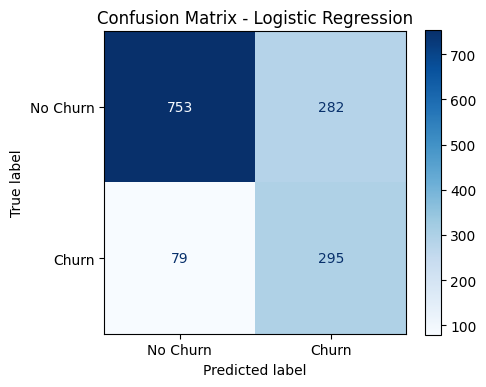


--- Random Forest Final Performance ---
Accuracy : 0.7615
ROC-AUC  : 0.8375

              precision    recall  f1-score   support

    No Churn       0.90      0.76      0.82      1035
       Churn       0.54      0.76      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409



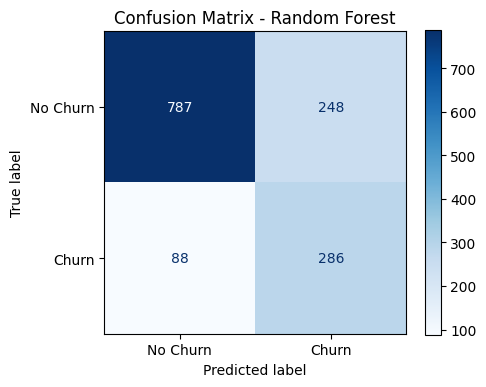


--- XGBoost Final Performance ---
Accuracy : 0.7587
ROC-AUC  : 0.8458

              precision    recall  f1-score   support

    No Churn       0.91      0.75      0.82      1035
       Churn       0.53      0.79      0.64       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409



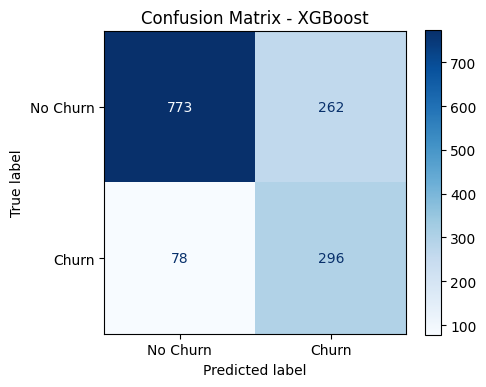

In [17]:
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    accuracy_score,
    roc_auc_score
)

def evaluate_final(model, name, x_val, y_val):
    y_pred = model.predict(x_val)
    y_prob = model.predict_proba(x_val)[:, 1]

    print(f"\n--- {name} Final Performance ---")
    print(f"Accuracy : {accuracy_score(y_val, y_pred):.4f}")
    print(f"ROC-AUC  : {roc_auc_score(y_val, y_prob):.4f}\n")

    print(classification_report(
        y_val,
        y_pred,
        target_names=['No Churn', 'Churn']
    ))

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_val,
        y_pred,
        ax=ax,
        cmap='Blues',
        display_labels=['No Churn', 'Churn']
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.tight_layout()
    plt.show()

evaluate_final(grid_lr, "Logistic Regression", x_test, y_test)
evaluate_final(grid_rf, "Random Forest", x_test, y_test)
evaluate_final(grid_xgb, "XGBoost", x_test, y_test)


In [18]:
from catboost import CatBoostClassifier

In [19]:
# CatBoost Pipeline

pipe_cat = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', CatBoostClassifier(
        random_state=42,
        verbose=0
    ))
])

In [20]:
# Hyperparameter Tuning - CatBoost

param_grid_cat = {
    'classifier__iterations': [200, 400],
    'classifier__depth': [4, 6, 8],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__l2_leaf_reg': [3, 5, 7]
}

grid_cat = HalvingGridSearchCV(
    pipe_cat,
    param_grid_cat,
    cv=5,
    factor=2,
    scoring='f1',
    n_jobs=-1,
    random_state=42
)

grid_cat.fit(x_train, y_train)

print("Best CatBoost Parameters:")
print(grid_cat.best_params_)

Best CatBoost Parameters:
{'classifier__depth': 4, 'classifier__iterations': 200, 'classifier__l2_leaf_reg': 7, 'classifier__learning_rate': 0.05}


In [21]:
# CatBoost Metrics

cat_metrics = get_metrics(
    grid_cat,
    x_test,
    y_test
)

pd.DataFrame(cat_metrics, index=["CatBoost"])

,Accuracy,Precision,Recall,F1-Score
CatBoost,0.802697,0.66,0.529412,0.587537



--- CatBoost Final Performance ---
Accuracy : 0.8027
ROC-AUC  : 0.8469

              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.66      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



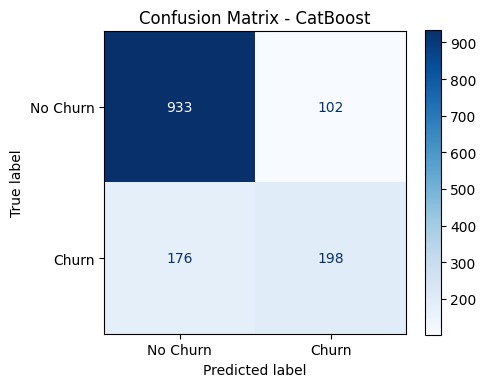

In [22]:
evaluate_final(
    grid_cat,
    "CatBoost",
    x_test,
    y_test
)

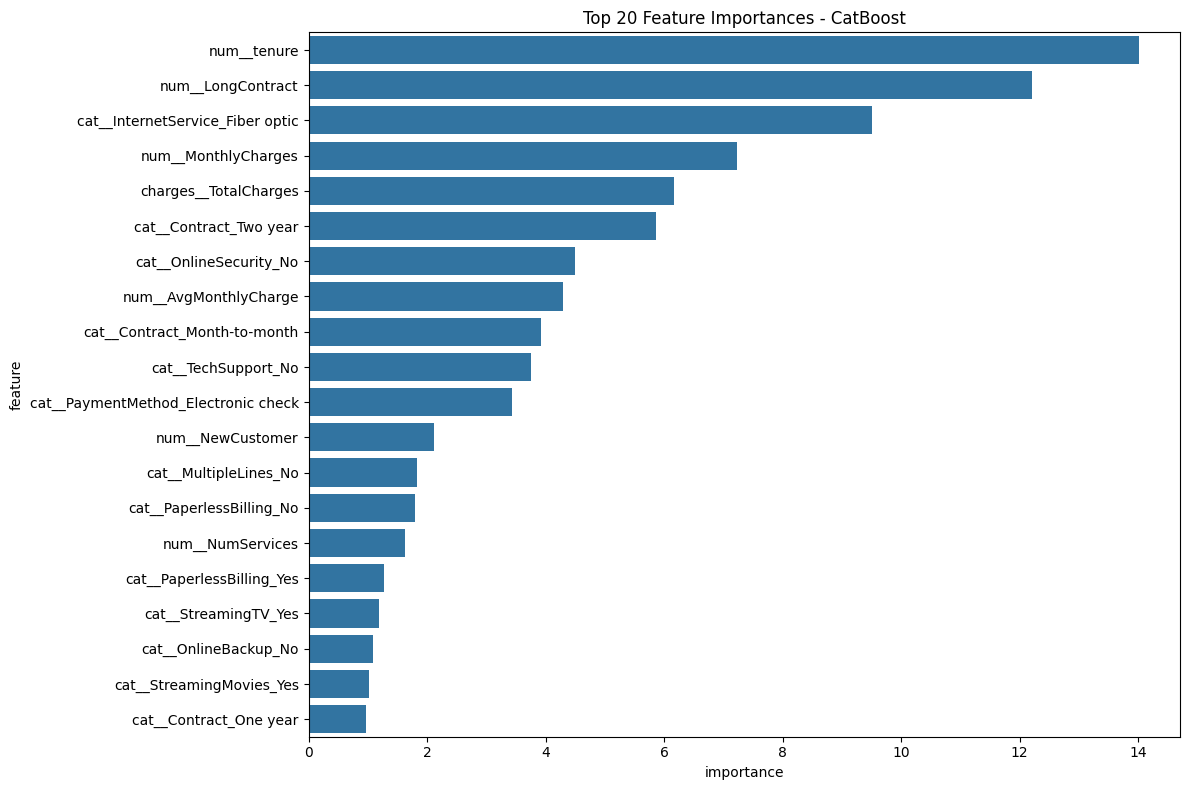

,feature,importance
2,num__tenure,14.004191
6,num__LongContract,12.205053
20,cat__InternetService_Fiber optic,9.506411
3,num__MonthlyCharges,7.223208
0,charges__TotalCharges,6.165989
42,cat__Contract_Two year,5.870239
22,cat__OnlineSecurity_No,4.501193
4,num__AvgMonthlyCharge,4.302155
40,cat__Contract_Month-to-month,3.915387
31,cat__TechSupport_No,3.751107


In [23]:
best_pipeline_cat = grid_cat.best_estimator_

preprocessor_cat = best_pipeline_cat.named_steps["preprocessor"]

best_cat_model = best_pipeline_cat.named_steps["classifier"]

feature_names = preprocessor_cat.get_feature_names_out()

importances_cat = pd.DataFrame({
    "feature": feature_names,
    "importance": best_cat_model.feature_importances_
}).sort_values(
    by="importance",
    ascending=False
)

plt.figure(figsize=(12,8))

sns.barplot(
    data=importances_cat.head(20),
    x="importance",
    y="feature"
)

plt.title("Top 20 Feature Importances - CatBoost")

plt.tight_layout()

plt.show()

importances_cat.head(20)

In [24]:
from sklearn.metrics import precision_recall_fscore_support

thresholds = np.arange(0.20, 0.81, 0.01)

y_prob = grid_cat.predict_proba(x_test)[:, 1]

results = []

for threshold in thresholds:

    y_pred = (y_prob >= threshold).astype(int)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        average="binary"
    )

    results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

threshold_results = pd.DataFrame(results)

best_threshold = threshold_results.loc[
    threshold_results["F1"].idxmax()
]

threshold_results.sort_values(
    by="F1",
    ascending=False
).head(10)

,Threshold,Precision,Recall,F1
15,0.35,0.566038,0.721925,0.634548
9,0.29,0.531646,0.786096,0.634304
12,0.32,0.546512,0.754011,0.633708
14,0.34,0.555781,0.732620,0.632065
13,0.33,0.548134,0.745989,0.631937
10,0.30,0.533088,0.775401,0.631808
7,0.27,0.517065,0.810160,0.631250
16,0.36,0.567164,0.711230,0.631079
18,0.38,0.578125,0.692513,0.630170
8,0.28,0.521968,0.794118,0.629905


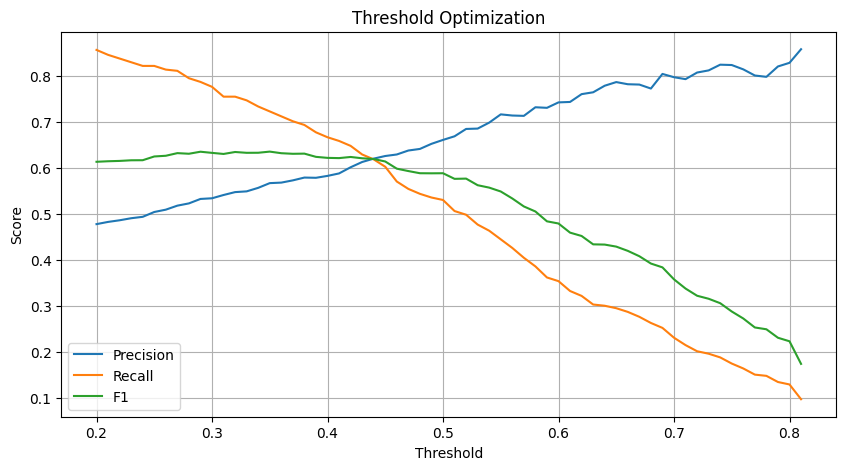

In [25]:
plt.figure(figsize=(10,5))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1"],
    label="F1"
)

plt.xlabel("Threshold")

plt.ylabel("Score")

plt.title("Threshold Optimization")

plt.grid(True)

plt.legend()

plt.show()

              precision    recall  f1-score   support

    No Churn       0.89      0.80      0.84      1035
       Churn       0.57      0.72      0.63       374

    accuracy                           0.78      1409
   macro avg       0.73      0.76      0.74      1409
weighted avg       0.80      0.78      0.79      1409



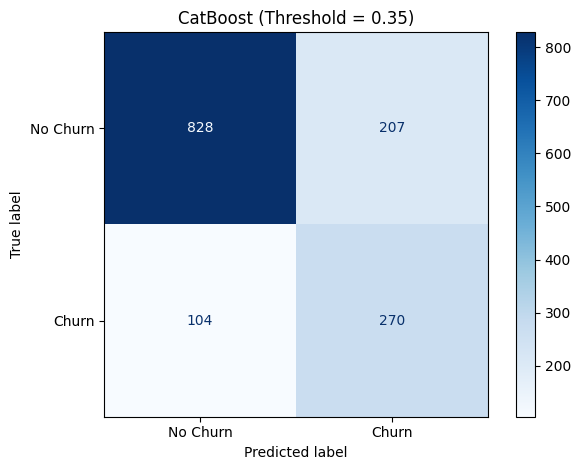

In [26]:
best_t = best_threshold["Threshold"]

y_pred = (
    grid_cat.predict_proba(x_test)[:,1] >= best_t
).astype(int)

print(classification_report(
    y_test,
    y_pred,
    target_names=[
        "No Churn",
        "Churn"
    ]
))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=[
        "No Churn",
        "Churn"
    ],
    cmap="Blues"
)

plt.title(
    f"CatBoost (Threshold = {best_t:.2f})"
)

plt.tight_layout()

plt.show()

- Instead of using the default classification threshold (0.50), multiple thresholds ranging from 0.20 to 0.80 were evaluated. The optimal threshold was selected based on the highest F1-score on the evaluation set. The best performance was achieved at a threshold of 0.35, resulting in a better balance between Precision (0.566), Recall (0.722), and F1-score (0.635) for the churn class.

In [27]:
import joblib

joblib.dump(grid_xgb, 'churn_model.pkl')

print("Best model (XGBoost) has been successfully saved as 'churn_model.pkl'! 🎉")

Best model (XGBoost) has been successfully saved as 'churn_model.pkl'! 🎉
